# Tier 1: PAF-shift model of a national MMN-fortified bouillon program in Ghana

Translates the CoMIT trial premix (vitamin A, B12, folic acid, iron, zinc,
iodine in bouillon cubes) into population-level DALYs and deficiency cases
averted, using the comparative-risk-assessment identity: shift the exposure,
recompute the PAF, difference the attributable burden.

**Status: PROVISIONAL.** The GBD MCP was not reachable when this was built,
so burden anchors marked `PROVISIONAL_PULL` in `data/gbd_anchors.csv` are
order-of-magnitude estimates pending draw-level GBD 2023 pulls. Survey
anchors (Ghana Micronutrient Survey 2017) and GBD 2019 relative risks are
real. Treat pathway *rankings* as informative and absolute numbers as
placeholders.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import model

anchors = pd.read_csv("data/gbd_anchors.csv").set_index("parameter")
a = anchors["value"]
anchors[["value", "units", "source", "status"]]

,value,units,source,status
parameter,,,,
pop_total,3.410000e+07,persons,World Bank 2024 estimate,PROVISIONAL
births_per_year,8.700000e+05,births/yr,UN WPP ~2024,PROVISIONAL
pop_children_6_59mo,3.900000e+06,persons,births x 4.5y survival approx,PROVISIONAL
pop_wra,8.700000e+06,persons,UN WPP ~2024 women 15-49,PROVISIONAL
pregnancies_per_year,1.000000e+06,pregnancies/yr,births + losses approx,PROVISIONAL
prev_vad_children,2.080000e-01,proportion,Ghana Micronutrient Survey 2017 (children 6-59mo),SURVEY
prev_anemia_wra,2.170000e-01,proportion,GMS 2017 non-pregnant women 15-49,SURVEY
prev_anemia_children,3.560000e-01,proportion,GMS 2017 children 6-59mo,SURVEY
prev_irondef_wra,1.370000e-01,proportion,GMS 2017 (ferritin-based),SURVEY


## Scenarios

Coverage = share of households regularly cooking with (now-fortified)
bouillon × fortified market share. The premix error in the trial (vitamin A
delivered at ~50–73% of target) becomes scenario S2.

In [2]:
scenarios = pd.DataFrame(
    [
        ("S1 program as intended", 0.77, 0.95, "full"),
        ("S2 program as delivered", 0.77, 0.95, "delivered"),
        ("S3 low coverage", 0.50, 0.95, "full"),
        ("S4 high coverage", 0.95, 0.95, "full"),
    ],
    columns=["scenario", "hh_coverage", "market_share", "va_dose"],
).set_index("scenario")
scenarios["coverage"] = scenarios.hh_coverage * scenarios.market_share
scenarios

,hh_coverage,market_share,va_dose,coverage
scenario,,,,
S1 program as intended,0.77,0.95,full,0.7315
S2 program as delivered,0.77,0.95,delivered,0.7315
S3 low coverage,0.50,0.95,full,0.4750
S4 high coverage,0.95,0.95,full,0.9025


## Pathway calculations

- **Vitamin A** (children 6–59 mo): resolve VAD in a share of covered
  deficient children; PAF shift against under-5 diarrhea and measles DALYs
  with GBD 2019 RRs (1.14 and 1.39 — note how much smaller than pre-2019
  rounds; LRI is no longer a VAD outcome).
- **Zinc** (children): same structure, diarrhea only.
- **Iron (a)** anemia YLDs via a normal-hemoglobin-distribution shift among
  covered iron-responsive WRA; **(b)** maternal disorders via a log-linear
  hemoglobin RR; **(c)** extended: LBW → neonatal deaths, with the
  supplementation RR scaled down to a bouillon dose on the log scale.
- **Folic acid**: NTD births averted among covered periconceptional women.
- **B12**: cases of deficiency resolved only — GBD has no B12 risk pathway.

In [3]:
def run_scenario(cov, va_dose):
    eff_va = a.efficacy_va_full if va_dose == "full" else a.efficacy_va_delivered
    rows = {}

    rows["VA: child diarrhea DALYs"] = model.dalys_averted_dichotomous(
        a.prev_vad_children, cov, eff_va, a.rr_vad_diarrhea, a.daly_u5_diarrhea)
    rows["VA: child measles DALYs"] = model.dalys_averted_dichotomous(
        a.prev_vad_children, cov, eff_va, a.rr_vad_measles, a.daly_u5_measles)
    rows["Zinc: child diarrhea DALYs"] = model.dalys_averted_dichotomous(
        a.prev_zincdef_children, cov, a.efficacy_zinc, a.rr_zinc_diarrhea,
        a.daly_u5_diarrhea)

    anemia_frac = model.anemia_reduction(
        a.hb_mean_wra, a.hb_sd_wra, a.dhb_regular_consumer, cov,
        a.iron_responsive_share)
    rows["Iron (a): anemia YLDs"] = anemia_frac * a.yld_anemia_wra
    rows["Iron (b): maternal DALYs"] = model.maternal_dalys_averted(
        a.daly_maternal, a.dhb_regular_consumer, cov, a.rr_maternal_per_10gL)
    neo_dalys, neo_deaths = model.neonatal_dalys_averted(
        a.neonatal_deaths, a.lbw_attrib_neonatal_share, a.rr_lbw_iron_supp,
        a.iron_dose_ratio_vs_supp, cov, a.yll_per_neonatal_death)
    rows["Iron (c): neonatal DALYs (extended)"] = neo_dalys

    ntd_dalys, ntd_births = model.ntd_dalys_averted(
        a.births_per_year, a.ntd_birth_prev, a.ntd_preventable_frac, cov,
        a.daly_per_ntd_birth)
    rows["Folic acid: NTD DALYs"] = ntd_dalys

    return pd.Series(rows), neo_deaths, ntd_births


results = {}
extras = {}
for name, s in scenarios.iterrows():
    results[name], neo_deaths, ntd_births = run_scenario(s.coverage, s.va_dose)
    extras[name] = {"neonatal deaths averted": neo_deaths,
                    "NTD births averted": ntd_births}

dalys = pd.DataFrame(results).round(0).astype(int)
dalys.loc["TOTAL DALYs/yr"] = dalys.sum()
dalys

,S1 program as intended,S2 program as delivered,S3 low coverage,S4 high coverage
VA: child diarrhea DALYs,2028,757,1313,2507
VA: child measles DALYs,623,230,401,773
Zinc: child diarrhea DALYs,1806,1806,1170,2232
Iron (a): anemia YLDs,2915,2915,1893,3596
Iron (b): maternal DALYs,5109,5109,3317,6303
Iron (c): neonatal DALYs (extended),10494,10494,6814,12947
Folic acid: NTD DALYs,18328,18328,11902,22613
TOTAL DALYs/yr,41303,39639,26810,50971


## Cases averted (including the B12 endpoint, which has no DALY translation)

In [4]:
cases = {}
for name, s in scenarios.iterrows():
    cov = s.coverage
    eff_va = (a.efficacy_va_full if s.va_dose == "full"
              else a.efficacy_va_delivered)
    cases[name] = {
        "child VAD cases resolved": model.cases_averted(
            a.prev_vad_children, a.pop_children_6_59mo, cov, eff_va),
        "child zinc deficiency resolved": model.cases_averted(
            a.prev_zincdef_children, a.pop_children_6_59mo, cov,
            a.efficacy_zinc),
        "WRA anemia cases averted": (
            model.anemia_reduction(a.hb_mean_wra, a.hb_sd_wra,
                                   a.dhb_regular_consumer, cov,
                                   a.iron_responsive_share)
            * a.prev_anemia_wra * a.pop_wra),
        "WRA B12 deficiency resolved (no DALY frame)": model.cases_averted(
            a.prev_b12def_wra, a.pop_wra, cov, a.efficacy_b12),
        **extras[name],
    }
pd.DataFrame(cases).round(0).astype(int)

,S1 program as intended,S2 program as delivered,S3 low coverage,S4 high coverage
child VAD cases resolved,237357,89009,154128,292843
child zinc deficiency resolved,213964,213964,138938,263981
WRA anemia cases averted,91718,91718,59557,113158
WRA B12 deficiency resolved (no DALY frame),131736,131736,85543,162531
neonatal deaths averted,122,122,79,151
NTD births averted,305,305,198,377


## Which pathways dominate?

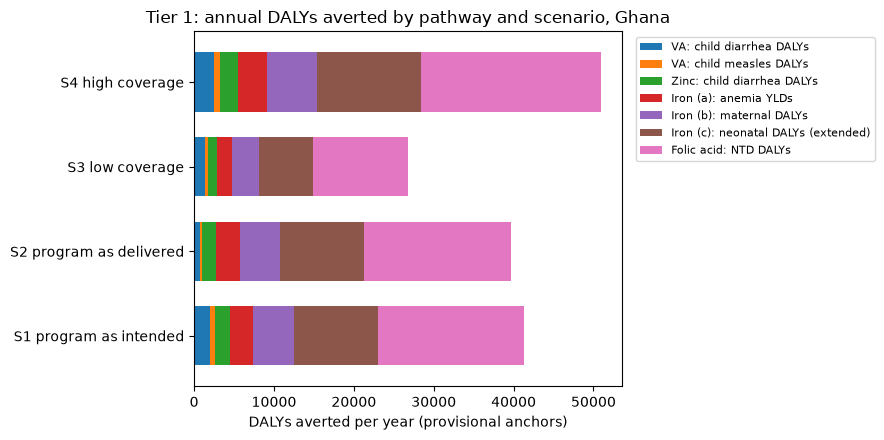

In [5]:
plot_df = dalys.drop("TOTAL DALYs/yr").T
ax = plot_df.plot.barh(stacked=True, figsize=(9, 4.5), width=0.7)
ax.set_xlabel("DALYs averted per year (provisional anchors)")
ax.set_title("Tier 1: annual DALYs averted by pathway and scenario, Ghana")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("dalys_averted_by_pathway.png", dpi=150)
plt.show()

## One-way sensitivity (tornado) on the S1 total

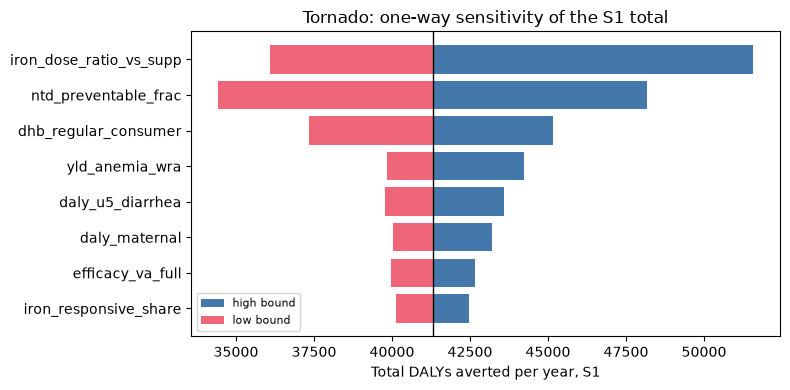

In [6]:
sensitive = ["dhb_regular_consumer", "iron_responsive_share",
             "efficacy_va_full", "daly_u5_diarrhea", "yld_anemia_wra",
             "iron_dose_ratio_vs_supp", "ntd_preventable_frac",
             "daly_maternal"]

s1 = scenarios.loc["S1 program as intended"]
base_total = run_scenario(s1.coverage, s1.va_dose)[0].sum()

tornado = []
for p in sensitive:
    saved = a[p]
    for bound, col in [("lo", "low"), ("hi", "high")]:
        a[p] = anchors.loc[p, bound]
        total = run_scenario(s1.coverage, s1.va_dose)[0].sum()
        tornado.append({"parameter": p, "bound": col, "total": total})
    a[p] = saved

tor = (pd.DataFrame(tornado)
       .pivot(index="parameter", columns="bound", values="total"))
tor["swing"] = (tor.high - tor.low).abs()
tor = tor.sort_values("swing")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tor.index, tor.high - base_total, left=base_total, color="#4477aa",
        label="high bound")
ax.barh(tor.index, tor.low - base_total, left=base_total, color="#ee6677",
        label="low bound")
ax.axvline(base_total, color="k", lw=1)
ax.set_xlabel("Total DALYs averted per year, S1")
ax.set_title("Tornado: one-way sensitivity of the S1 total")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("tornado_s1.png", dpi=150)
plt.show()

## Read-out and next steps

With provisional anchors, **folic acid and iron dominate the DALYs**, not
vitamin A. Folic acid contributes ~45% of the S1 total despite averting only
~300 NTD births/yr, because each carries decades of DALYs; the three iron
components together contribute ~45% more, led by the extended neonatal
chain. Vitamin A — historically the headline pathway for fortification —
contributes under 10%, because GBD 2019 cut its diarrhea RR from 2.35 to
1.14 and dropped LRI as an outcome entirely; a GBD-2017-era analysis would
have told a very different story. The premix-error scenario (S2) barely
moves the total for the same reason. The B12 result — the trial's strongest
finding — appears only in the cases table, by design.

Before believing absolute numbers:

1. Replace every `PROVISIONAL_PULL` anchor with draw-level GBD 2023 pulls
   for Ghana (under-5 diarrhea/measles DALYs, anemia YLD envelope and its
   causal attribution, maternal-disorder DALYs and hemoglobin RRs, LBWSG
   attributable share).
2. Pull the iron/zinc/folic acid premix doses from the CoMIT protocol
   (`TO_PULL` rows) and replace the assumed effect parameters with
   dose-informed ones; update B12 and hemoglobin effects when the companion
   CoMIT status paper (Arnold et al. SAP) publishes.
3. Propagate uncertainty properly (Monte Carlo over the lo/hi ranges, or
   GBD draws) instead of the one-way tornado.